In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys

sys.path.append('//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses')
sys.path.append('//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/langevin-sindy')

import utils.preprocess as pp

In [9]:
path_to_jepa = "//allen/aics/assay-dev/users/Benji/cellsmap/results/jepa/predictions.csv"
df = pd.read_csv(path_to_jepa)

# add crop location index as metadata
num_loc = 54
num_T = 577
loc_idx = np.tile(np.arange(0, num_loc), num_T)

# add crop index to dataframe
df['loc_idx'] = loc_idx
df = df.sort_values(by=['loc_idx','T'])

df.columns[-1]


'loc_idx'

In [10]:
np.unique(df['loc_idx'].values)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53])

In [7]:

# get array of MAE features
X_feats = pp.get_array(df,metadata_col=['loc_idx','T'])
# z-score
X_scaled = pp.scale_features(X_feats)

# build dataframe of scaled data, leaving out crop path metadata
data_scaled = np.hstack((X_scaled,df['T'].values[:,None],df['loc_idx'].values[:,None]))
cols = df.columns
df_scaled = pd.DataFrame(data_scaled,columns=cols)
df_scaled['loc_idx'] = df_scaled['loc_idx'].astype(int)
df_scaled['T'] = df_scaled['T'].astype(int)

In [8]:
X_scaled.shape

(31158, 256)

In [4]:
svs = np.load('../data/JEPA_SVs.npy')
exp_var = np.load('../data/JEPA_ExpVar.npy')
pcs = np.load('../data/JEPA_PCs.npy')

Number of modes to explain 95% of variance:  2


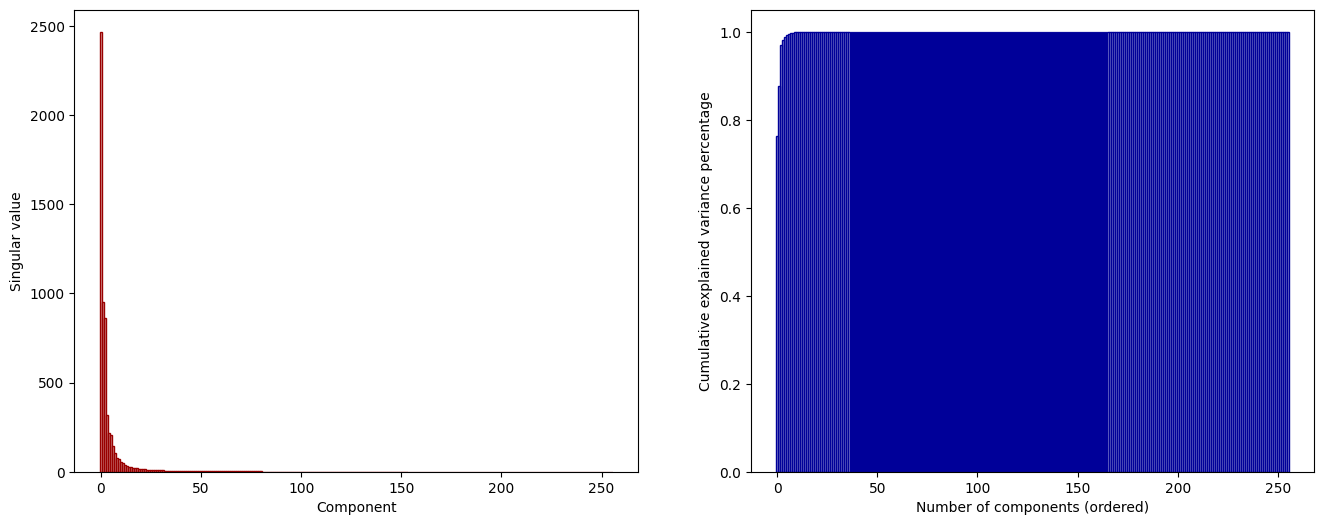

In [5]:
fig, ax = plt.subplots(1,2, figsize=(16,6))
m=len(svs)
ax[0].bar(np.arange(m),svs, color=(0.6,0,0.0,0.3),edgecolor=(0.6,0,0.0,1.0))
ax[0].set_xlabel("Component")
ax[0].set_ylabel("Singular value")

ax[1].bar(np.arange(m),np.cumsum(exp_var),color=(0.0,0,0.6,0.3),edgecolor=(0.0,0,0.6,1.0))
ax[1].set_xlabel("Number of components (ordered)")
ax[1].set_ylabel("Cumulative explained variance percentage")

num_modes_95 = np.where(np.cumsum(exp_var) > 0.95)[0].min()
print("Number of modes to explain 95% of variance: ", num_modes_95)

Text(0, 0.5, 'Cumulative explained variance percentage')

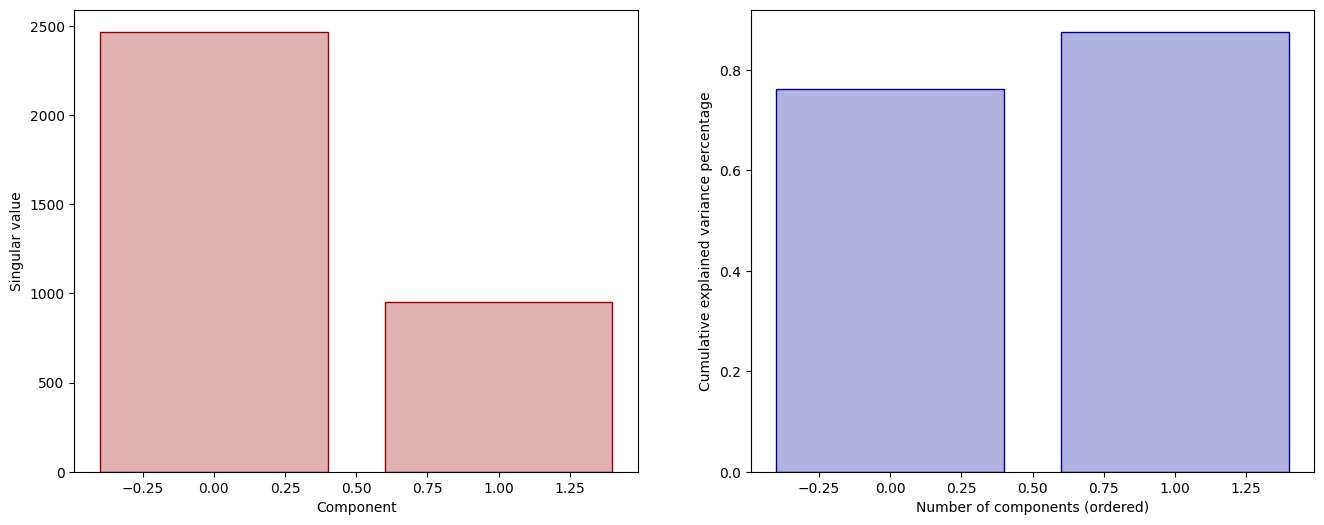

In [6]:
fig, ax = plt.subplots(1,2, figsize=(16,6))

ax[0].bar(np.arange(num_modes_95),svs[:num_modes_95], color=(0.6,0,0.0,0.3),edgecolor=(0.6,0,0.0,1.0))
ax[0].set_xlabel("Component")
ax[0].set_ylabel("Singular value")

ax[1].bar(np.arange(num_modes_95),np.cumsum(exp_var)[:num_modes_95],color=(0.0,0,0.6,0.3),edgecolor=(0.0,0,0.6,1.0))
ax[1].set_xlabel("Number of components (ordered)")
ax[1].set_ylabel("Cumulative explained variance percentage")

In [7]:
X_t = np.load('../data/JEPA_95pctVarPCs_all.npy') # preprocessed data: num_loc * num_timepoints * num_modes_95 array
X_pca = X_t.reshape((-1,num_modes_95))[:,:2] # truncated to top 2 modes

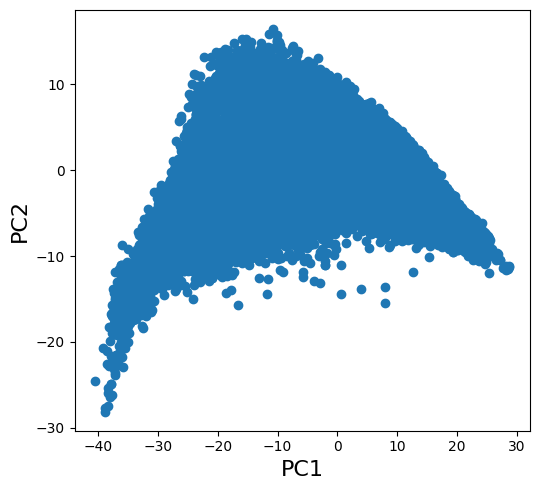

In [8]:
fig, ax = plt.subplots(1,1, figsize=(5.5,5))
sc_plt = ax.scatter(X_pca[:,0], X_pca[:,1]) 
ax.set_xlabel("PC1", fontsize=16)
ax.set_ylabel("PC2", fontsize=16)
plt.tight_layout()

In [9]:
X_t_high = np.load('../data/JEPA_95pctVarPCs_highFlow.npy')
X_t_low = np.load('../data/JEPA_95pctVarPCs_lowFlow.npy')

num_loc = X_t.shape[0]
num_t = X_t.shape[1]
t_change = (24*60 - 25)//5 # time point (frame number) at which to change from high to low flow occurs (25 minutes before 24 hours)

Text(0, 0.5, 'PC1')

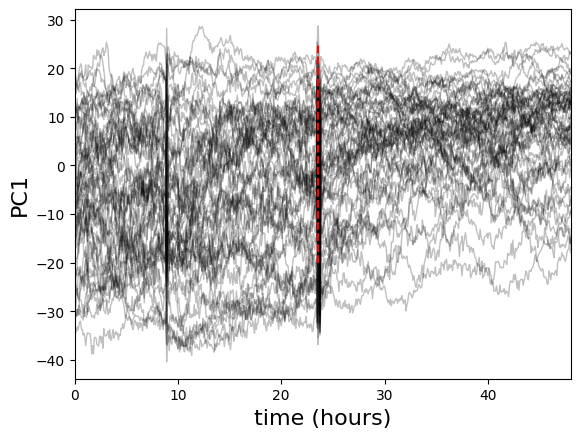

In [10]:
# plot top PCA mode vs time for each location at high flow
for i in range(num_loc):
    plt.plot(5*np.arange(num_t)/60,X_t[i,:,0],'k-',alpha=0.25,linewidth=1)
plt.xlim([0,(num_t)*5//60])
plt.vlines(5*t_change/60,-20,25,color='r',linestyles='dashed')
#plt.vlines(530/60,-20,25,color='b',linestyles='dashed')
plt.xlabel("time (hours)", fontsize=16)
plt.ylabel("PC1", fontsize=16)

Text(0, 0.5, 'PC2')

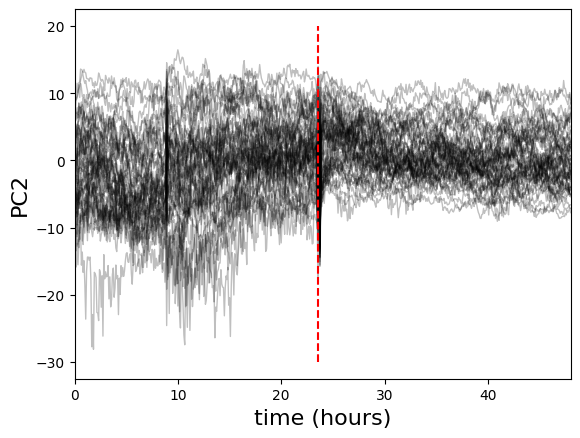

In [11]:
# plot PCA mode m vs time for each location at high flow
m=2

for i in range(num_loc):
    plt.plot(5*np.arange(num_t)/60,X_t[i,:,m-1],'k-',alpha=0.25,linewidth=1)
plt.xlim([0,(num_t)*5//60])
plt.vlines(5*t_change/60,-30,20,color='r',linestyles='dashed')
#plt.vlines(530/60,-20,25,color='b',linestyles='dashed')
plt.xlabel("time (hours)", fontsize=16)
plt.ylabel("PC"+str(m), fontsize=16)

Text(0, 0.5, 'PC2')

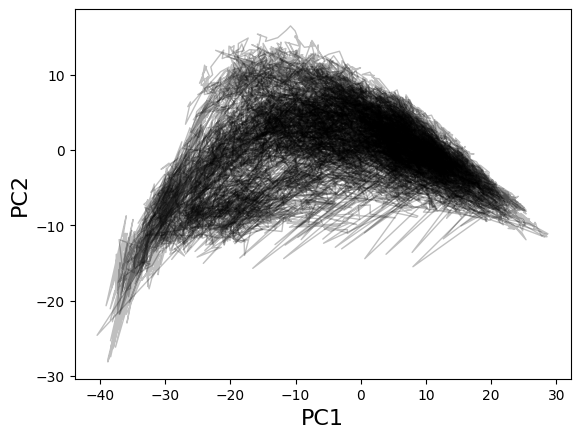

In [12]:
for i in range(num_loc):
    plt.plot(X_t[i,:,0],X_t[i,:,1],'k-',alpha=0.25,linewidth=1)
#plt.xlim([0,(num_t)*5])
plt.xlabel("PC1", fontsize=16)
plt.ylabel("PC2", fontsize=16)

Text(0, 0.5, 'PC2')

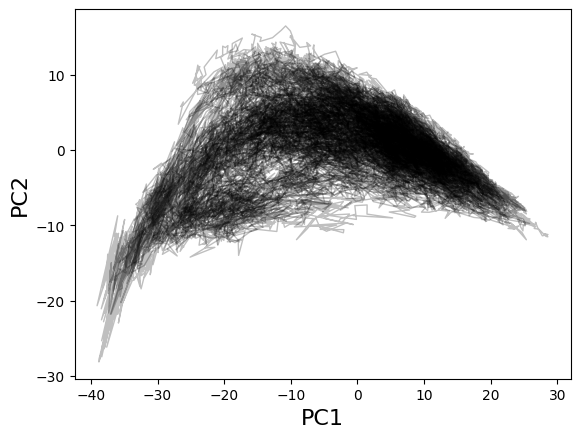

In [14]:
no_spike = np.r_[0:106, 108:t_change, t_change+3:num_t]
for i in range(num_loc):
    plt.plot(X_t[i,no_spike,0],X_t[i,no_spike,1],'k-',alpha=0.25,linewidth=1)
#plt.xlim([0,(num_t)*5])
plt.xlabel("PC1", fontsize=16)
plt.ylabel("PC2", fontsize=16)

In [15]:
import matplotlib.cm as cm
from scipy import stats
from scipy.optimize import minimize, NonlinearConstraint

Slope:  -0.3312815016130905
Intercept:  1.0074858729982084


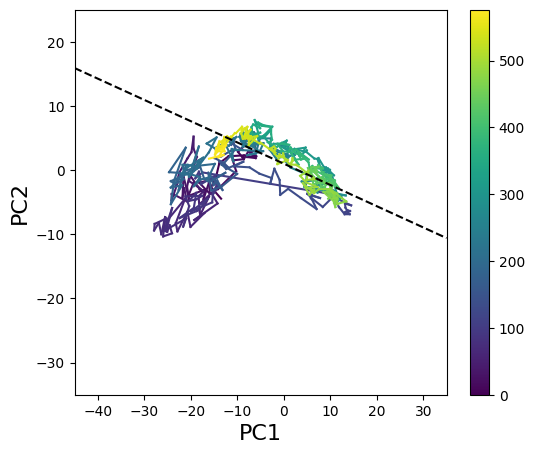

In [16]:
i=7
x = X_t[i,no_spike,0]
y = X_t[i,no_spike,1]


tvec = np.arange(num_t)[no_spike]
col = cm.viridis((tvec-np.min(tvec))/(np.max(tvec)-np.min(tvec)))

slope, intercept, r, p, std_err = stats.linregress(x[-200:], y[-200:])
xvec = np.linspace(-45,35,100)

fig = plt.figure(1, figsize=(6,5))
ax = plt.gca()
for i in np.arange(len(x)-1):
    ax.plot([x[i],x[i+1]], [y[i],y[i+1]], c=col[i])
        
im = ax.scatter(x, y, c=tvec, s=0, cmap=cm.viridis)
fig.colorbar(im)
plt.xlim([-45,35])
plt.ylim([-35,25])
plt.xlabel("PC1", fontsize=16)
plt.ylabel("PC2", fontsize=16)
plt.plot(xvec, slope*xvec + intercept, 'k--')
print("Slope: ", slope)
print("Intercept: ", intercept)

In [17]:
x = X_t[:,no_spike,0].flatten()
y = X_t[:,no_spike,1].flatten()

def p(X,Y,coeff):
    a,b,c,d,e,f = coeff
    return a*X**2 + b*X*Y + c*Y**2 + d*X + e*Y + f

def my_func(coeff):
    return p(x,y,coeff)

def opt_func(coeff):
    return np.abs(my_func(coeff)).max()

def constr_func(coeff):
    return coeff[1]**2 - 4*coeff[0]*coeff[2]

my_constr = NonlinearConstraint(constr_func, 0, 0)

In [18]:
res = minimize(opt_func, np.ones(6), constraints=my_constr)
coef = res.x
print(coef)

[ 1.00222818e-06  4.14922272e-07 -5.15536514e-07  1.44651729e-05
  3.49859862e-05 -1.22925294e-04]


In [19]:
a,b,c,d,e,f = coef
b**2 - 4*a*c

2.2389013806149146e-12

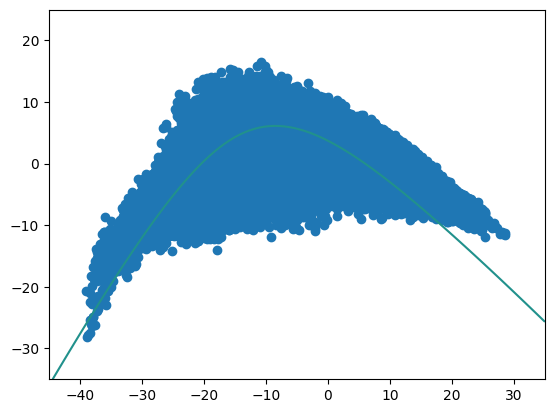

In [20]:
X,Y = np.meshgrid(np.linspace(-45,35,100),np.linspace(-35,25,100))
Z = p(X,Y,coef)
plt.contour(X,Y,Z,levels=0)
plt.scatter(x,y)

In [21]:
X_scaled = np.load('../data/JEPA_feats_normed.npy')
print(X_scaled.shape)
X_scaled = X_scaled.reshape((num_loc,num_t,-1))

(31158, 256)


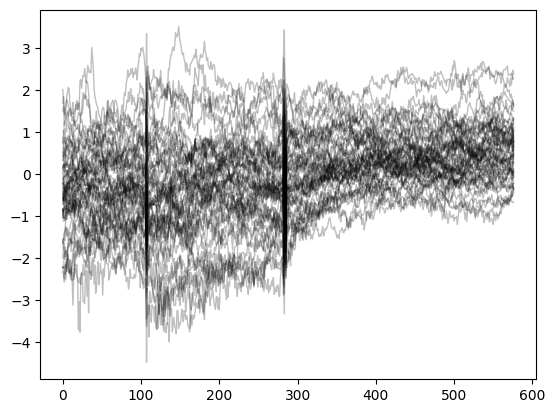

In [22]:
for i in range(num_loc):
    plt.plot(np.arange(num_t),X_scaled[i,:,0],'k-',alpha=0.25,linewidth=1)

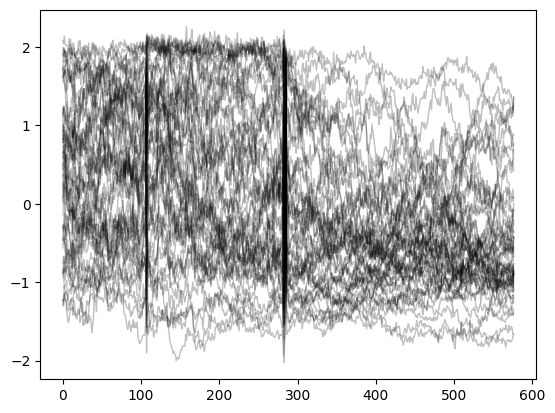

In [23]:
for i in range(num_loc):
    plt.plot(np.arange(num_t),X_scaled[i,:,1],'k-',alpha=0.25,linewidth=1)

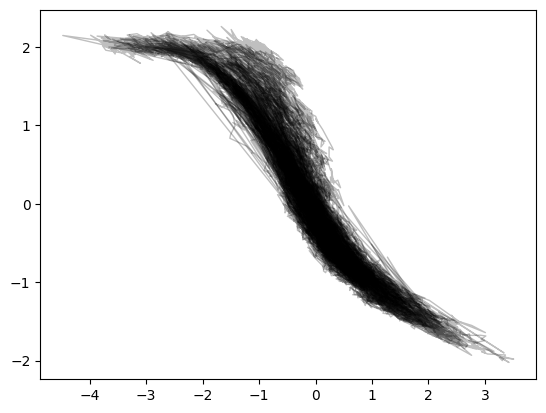

In [25]:
for i in range(num_loc):
    plt.plot(X_scaled[i,:,0],X_scaled[i,:,1],'k-',alpha=0.25,linewidth=1)

Text(0, 0.5, 'Feature 2')

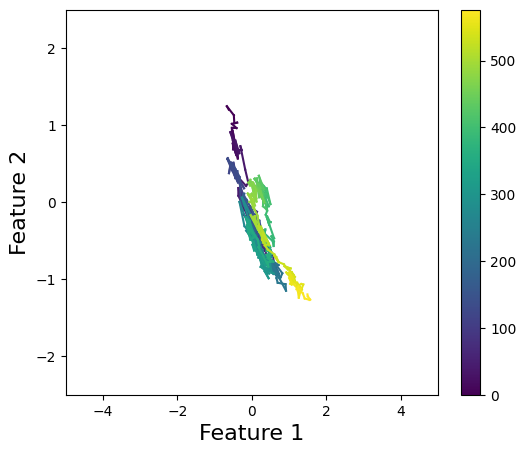

In [30]:
i=1
x = X_scaled[i,no_spike,0]
y = X_scaled[i,no_spike,1]


tvec = np.arange(num_t)[no_spike]
col = cm.viridis((tvec-np.min(tvec))/(np.max(tvec)-np.min(tvec)))

# slope, intercept, r, p, std_err = stats.linregress(x[-200:], y[-200:])
# xvec = np.linspace(-45,35,100)

fig = plt.figure(1, figsize=(6,5))
ax = plt.gca()
for i in np.arange(len(x)-1):
    ax.plot([x[i],x[i+1]], [y[i],y[i+1]], c=col[i])
        
im = ax.scatter(x, y, c=tvec, s=0, cmap=cm.viridis)
fig.colorbar(im)
plt.xlim([-5,5])
plt.ylim([-2.5,2.5])
plt.xlabel("Feature 1", fontsize=16)
plt.ylabel("Feature 2", fontsize=16)
# plt.plot(xvec, slope*xvec + intercept, 'k--')
# print("Slope: ", slope)
# print("Intercept: ", intercept)

In [31]:
diff = np.mean(np.abs(X_scaled[:,0,:] - X_scaled[:,-1,:]),axis=0)

In [33]:
np.argmax(diff)

212

In [34]:
np.max(diff)

1.4692822832615315

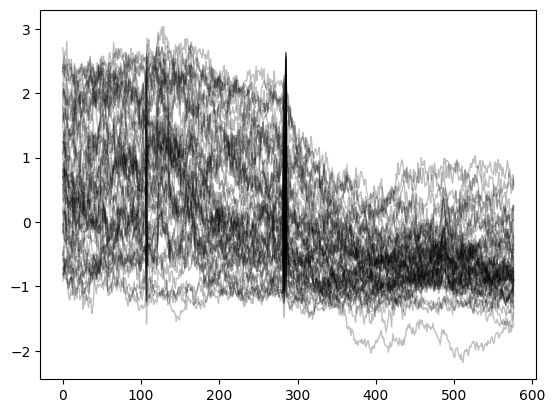

In [36]:
for i in range(num_loc):
    plt.plot(np.arange(num_t),X_scaled[i,:,212],'k-',alpha=0.25,linewidth=1)